# VLAB_05 — Local Sensitivity Analysis

One-factor-at-a-time (OAT) sensitivity analysis of karst spring discharge to seven independent sources of variability.
Each group is varied in isolation while all other parameters are held at their default values.
A single reference simulation (all defaults) serves as the baseline.

| Group | Source of variability | Approach |
|---|---|---|
| G1 | Recharge model parameters | `RechargeParams(stochastic=True)` → `simulate_from_network` |
| G2 | Network realizations (`sks_seed`) | `NetworkStructure(stochastic=True)` → `simulate_full` |
| G3 | Inlet seed (sinkhole placement) | Explicit `inlets_seed` loop → `simulate_full` |
| G4 | Number of inlets (1–3) | Explicit `n_inlets` loop → `simulate_full` |
| G5 | Fracture family presets | Explicit `fracture_families` loop → `simulate_full` |
| G6 | Network hydraulic properties | `NetworkProperties(stochastic=True)` → `simulate_from_network` |
| G7 | Aquifer (matrix) properties | `AquiferParams(stochastic=True)` → `simulate_from_network` |

**Settings:** daily temporal resolution · 5 time steps per stress period · stress periods 81–100 (20 days)

In [1]:
# import sys
# sys.path.insert(0, "../..")

import vlab
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path

%matplotlib inline

## Configuration

In [2]:
# ── Number of simulations per stochastic group ────────────────────────────────
# Increase for a denser spread; decrease to cut run time.
N_RCH      = 5   # G1: recharge model parameter realizations
N_NET_REL  = 5   # G2: network realizations (varied sks_seed)
N_INL_SEED = 5   # G3: inlet placement seed realizations
N_NET_PROP = 5   # G6: network hydraulic property realizations
N_AQF      = 5   # G7: aquifer property realizations

# G3: explicit inlet seed values (length must equal N_INL_SEED)
INLET_SEEDS_G3 = [100, 200, 300, 400, 500]

# G4: number of inlets to test (always exactly these values)
N_INLETS_G4 = [1, 2, 3]

# ── Simulation settings ───────────────────────────────────────────────────────
NSTP = 5   # internal time steps per stress period
N_SP = 20  # number of transient stress periods (= len of sliced data)

# ── Color scheme — one color per variability group ────────────────────────────
COLORS = {
    "ref": "black",
    "G1":  "#1abc9c",        # teal   — recharge params
    "G2":  "steelblue",      # blue   — network realizations
    "G3":  "darkorange",     # orange — inlet seed
    "G4":  "mediumseagreen", # green  — number of inlets
    "G5":  "mediumpurple",   # purple — fracture families
    "G6":  "crimson",        # red    — network properties
    "G7":  "saddlebrown",    # brown  — aquifer params
}

GROUP_LABELS = {
    "G1": "Recharge params",
    "G2": "Network realizations",
    "G3": "Inlet seed",
    "G4": "Number of inlets",
    "G5": "Fracture families",
    "G6": "Network properties",
    "G7": "Aquifer params",
}

# ── Working directory ─────────────────────────────────────────────────────────
# Temporary pyKasso and MODFLOW files land here; cleanup=True removes them after each run.
WORKING_DIR = Path.cwd() / "runs"
WORKING_DIR.mkdir(exist_ok=True)

## Data Preparation

Slice the bundled daily climate series to stress periods 81–100 (20-day study window).

Study period: 2016-03-22 — 2016-04-10
Mean precip:  1.7 mm/d  |  Total precip: 34 mm


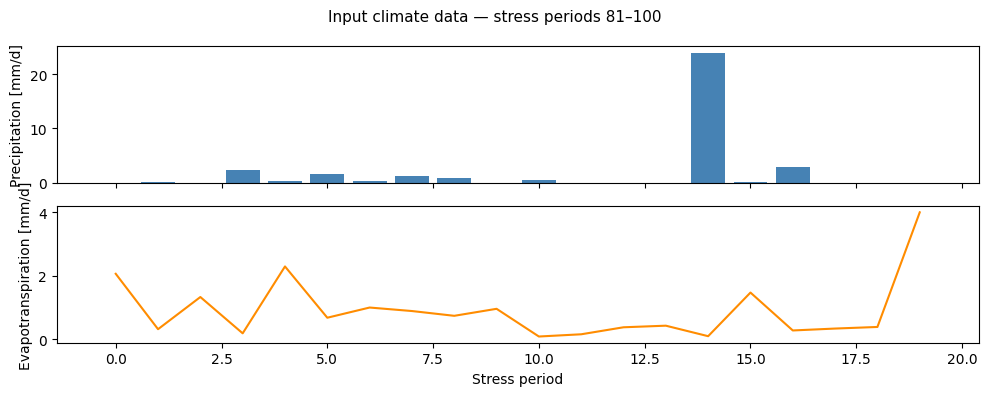

In [3]:
data_full = vlab.Data.default()
data = vlab.Data(data_full.prec.iloc[81:101], data_full.evap.iloc[81:101])

print(f"Study period: {data.prec.index[0].date()} — {data.prec.index[-1].date()}")
print(f"Mean precip:  {data.prec.mean():.1f} mm/d  |  "
      f"Total precip: {data.prec.sum():.0f} mm")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

ax1.bar(np.arange(N_SP), data.prec.values, color="steelblue", width=0.8)
ax1.set_ylabel("Precipitation [mm/d]")

ax2.plot(np.arange(N_SP), data.evap.values, color="darkorange", lw=1.5)
ax2.set_ylabel("Evapotranspiration [mm/d]")
ax2.set_xlabel("Stress period")

plt.suptitle("Input climate data — stress periods 81–100", fontsize=11)
plt.tight_layout()
plt.show()

## Fracture Family Presets (G5)

Five geologically distinct fracture configurations. All preserve the three-family structure
of the default network and vary only orientation, density, and length to produce
different hydraulic connectivity regimes.

| Preset | Dominant direction | Density | Fracture length |
|---|---|---|---|
| `NS_dominant` | N–S striking | high (family 1) + sparse others | medium |
| `EW_dominant` | E–W striking | high (family 1) + sparse others | medium |
| `diagonal` | NE–SW / NW–SE conjugate | medium, symmetric | medium |
| `dense_short` | default orientations | high (all) | short (100–200 m) |
| `sparse_long` | default orientations | low (all) | long (600–1100 m) |

In [4]:
FRACTURE_PRESETS = {
    "NS_dominant": {
        "family_01": {"density": 0.000012, "orientation": [160, 180], "dip": [90, 160], "length": [400, 600], "alpha": 1.5},
        "family_02": {"density": 0.000003, "orientation": [70,  90],  "dip": [90, 120], "length": [300, 400], "alpha": 1.5},
        "family_03": {"density": 0.000002, "orientation": [0,   20],  "dip": [90, 120], "length": [200, 300], "alpha": 1.5},
    },
    "EW_dominant": {
        "family_01": {"density": 0.000012, "orientation": [80,  100], "dip": [90, 160], "length": [400, 600], "alpha": 1.5},
        "family_02": {"density": 0.000003, "orientation": [150, 170], "dip": [90, 120], "length": [300, 400], "alpha": 1.5},
        "family_03": {"density": 0.000002, "orientation": [40,  60],  "dip": [90, 120], "length": [200, 300], "alpha": 1.5},
    },
    "diagonal": {
        "family_01": {"density": 0.000008, "orientation": [40,  60],  "dip": [90, 160], "length": [400, 500], "alpha": 1.5},
        "family_02": {"density": 0.000008, "orientation": [130, 150], "dip": [90, 120], "length": [400, 500], "alpha": 1.5},
        "family_03": {"density": 0.000004, "orientation": [85,  95],  "dip": [90, 120], "length": [300, 400], "alpha": 1.5},
    },
    "dense_short": {
        "family_01": {"density": 0.000015, "orientation": [130, 160], "dip": [90, 160], "length": [100, 200], "alpha": 1.5},
        "family_02": {"density": 0.000015, "orientation": [45,  80],  "dip": [90, 120], "length": [100, 200], "alpha": 1.5},
        "family_03": {"density": 0.000010, "orientation": [0,   60],  "dip": [90, 120], "length": [100, 200], "alpha": 1.5},
    },
    "sparse_long": {
        "family_01": {"density": 0.000003, "orientation": [130, 160], "dip": [90, 160], "length": [600,  900], "alpha": 1.5},
        "family_02": {"density": 0.000003, "orientation": [45,  80],  "dip": [90, 120], "length": [700, 1000], "alpha": 1.5},
        "family_03": {"density": 0.000002, "orientation": [0,   60],  "dip": [90, 120], "length": [800, 1100], "alpha": 1.5},
    },
}


def make_ref_system(**overrides):
    """
    Return a System with all parameter groups fixed at their defaults.

    Keyword arguments replace specific System constructor arguments, allowing
    any single group to be swapped out for the sensitivity experiment while
    all others remain at their default fixed values.
    """
    kw = dict(
        data=data,
        groundwater=vlab.Groundwater(nstp=NSTP),
        recharge_params=vlab.RechargeParams(stochastic=False),
        network_structure=vlab.NetworkStructure(stochastic=False),
        network_properties=vlab.NetworkProperties(stochastic=False),
        aquifer_params=vlab.AquiferParams(stochastic=False),
    )
    kw.update(overrides)
    return vlab.System(**kw)

## Reference Simulation

Generate the reference karst network and run a single simulation at all default parameters.
G1, G6, and G7 reuse this network to isolate parameter effects from network-geometry differences.

In [5]:
s_ref = make_ref_system()

print("Generating reference network...")
ref_network = s_ref.generate_network(
    random_state=None, working_dir=WORKING_DIR, cleanup=True
)
print(f"  inlets: {len(ref_network.idxs_inlet)}  |  spring: {ref_network.idxs_spring}")

print("Running reference simulation...")
ref_success, Q_ref, _ = s_ref.simulate_from_network(
    ref_network, random_state=None, working_dir=WORKING_DIR, cleanup=True
)

if not ref_success:
    raise RuntimeError("Reference simulation failed — check CFPv2.exe and model setup.")

Q_ref_plot = Q_ref.values[1:] * 1000   # skip SS warm-up, convert m³/s → L/s
t = np.arange(1, len(Q_ref_plot) + 1)  # 1 … N_SP * NSTP

print(f"  Q_peak = {Q_ref_plot.max():.4f} L/s  |  "
      f"Q_mean = {Q_ref_plot.mean():.4f} L/s  |  "
      f"Q_out length = {len(Q_ref_plot)} steps")

Generating reference network...

Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.
  inlets: 5  |  spring: [100, 17, 1]
Running reference simulation...
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.26 s
  Q_peak = 46.5687 L/s  |  Q_mean = 30.7670 L/s  |  Q_out length = 100 steps


## Sensitivity Groups

Run all seven variability groups. Failed runs (MODFLOW non-convergence) are skipped with a warning.

In [6]:
results = {g: [] for g in ["G1", "G2", "G3", "G4", "G5", "G6", "G7"]}


# ── G1: Recharge model parameters ────────────────────────────────────────────
# Only RechargeParams is stochastic; reference network is reused so that
# differences come purely from the epikarst recharge parameterisation.
print("G1: Recharge params...")
s_g1 = make_ref_system(recharge_params=vlab.RechargeParams(stochastic=True))
for rs in range(N_RCH):
    ok, Q, _ = s_g1.simulate_from_network(
        ref_network, random_state=rs, working_dir=WORKING_DIR, cleanup=True
    )
    if ok:
        results["G1"].append(Q.values)
    else:
        print(f"  WARNING G1 rs={rs} failed — skipping")
print(f"  {len(results['G1'])}/{N_RCH} successful")


# ── G2: Network realizations (sks_seed) ───────────────────────────────────────
# Only sks_seed is stochastic in NetworkStructure; each realisation produces
# a different conduit skeleton from the same fracture families and inlet placement.
print("G2: Network realizations...")
s_g2 = make_ref_system(network_structure=vlab.NetworkStructure(stochastic=True))
for rs in range(N_NET_REL):
    ok, Q, _ = s_g2.simulate_full(
        random_state=rs, working_dir=WORKING_DIR, cleanup=True
    )
    if ok:
        results["G2"].append(Q.values)
    else:
        print(f"  WARNING G2 rs={rs} failed — skipping")
print(f"  {len(results['G2'])}/{N_NET_REL} successful")


# ── G3: Inlet seed ────────────────────────────────────────────────────────────
# inlets_seed is a fixed structural parameter, so a new System is built for each
# seed value. The sks_seed and fracture families remain at defaults.
print("G3: Inlet seed...")
for seed_val in INLET_SEEDS_G3:
    s_g3 = make_ref_system(
        network_structure=vlab.NetworkStructure(stochastic=False, inlets_seed=seed_val)
    )
    ok, Q, _ = s_g3.simulate_full(
        random_state=None, working_dir=WORKING_DIR, cleanup=True
    )
    if ok:
        results["G3"].append(Q.values)
    else:
        print(f"  WARNING G3 inlets_seed={seed_val} failed — skipping")
print(f"  {len(results['G3'])}/{N_INL_SEED} successful")


# ── G4: Number of inlets ──────────────────────────────────────────────────────
# n_inlets controls how many sinkhole inlets are placed on the land surface.
print("G4: Number of inlets...")
for n_inl in N_INLETS_G4:
    s_g4 = make_ref_system(
        network_structure=vlab.NetworkStructure(stochastic=False, n_inlets=n_inl)
    )
    ok, Q, _ = s_g4.simulate_full(
        random_state=None, working_dir=WORKING_DIR, cleanup=True
    )
    if ok:
        results["G4"].append(Q.values)
    else:
        print(f"  WARNING G4 n_inlets={n_inl} failed — skipping")
print(f"  {len(results['G4'])}/{len(N_INLETS_G4)} successful")


# ── G5: Fracture family presets ───────────────────────────────────────────────
# Each preset replaces the three fracture families with a geologically distinct
# configuration while keeping the sks_seed and inlet placement at defaults.
print("G5: Fracture family presets...")
for preset_name, frac_config in FRACTURE_PRESETS.items():
    s_g5 = make_ref_system(
        network_structure=vlab.NetworkStructure(
            stochastic=False, fracture_families=frac_config
        )
    )
    ok, Q, _ = s_g5.simulate_full(
        random_state=None, working_dir=WORKING_DIR, cleanup=True
    )
    if ok:
        results["G5"].append(Q.values)
    else:
        print(f"  WARNING G5 preset={preset_name} failed — skipping")
print(f"  {len(results['G5'])}/{len(FRACTURE_PRESETS)} successful")


# ── G6: Network hydraulic properties ─────────────────────────────────────────
# Only NetworkProperties is stochastic (k_exchange, diameter, rheight, cad,
# crch_fraction); reference network is reused.
print("G6: Network hydraulic properties...")
s_g6 = make_ref_system(network_properties=vlab.NetworkProperties(stochastic=True))
for rs in range(N_NET_PROP):
    ok, Q, _ = s_g6.simulate_from_network(
        ref_network, random_state=rs, working_dir=WORKING_DIR, cleanup=True
    )
    if ok:
        results["G6"].append(Q.values)
    else:
        print(f"  WARNING G6 rs={rs} failed — skipping")
print(f"  {len(results['G6'])}/{N_NET_PROP} successful")


# ── G7: Aquifer (matrix) properties ──────────────────────────────────────────
# Only AquiferParams is stochastic (hk, ss, sy); reference network is reused.
print("G7: Aquifer params...")
s_g7 = make_ref_system(aquifer_params=vlab.AquiferParams(stochastic=True))
for rs in range(N_AQF):
    ok, Q, _ = s_g7.simulate_from_network(
        ref_network, random_state=rs, working_dir=WORKING_DIR, cleanup=True
    )
    if ok:
        results["G7"].append(Q.values)
    else:
        print(f"  WARNING G7 rs={rs} failed — skipping")
print(f"  {len(results['G7'])}/{N_AQF} successful")


print("\nAll groups complete.")
for gk in ["G1","G2","G3","G4","G5","G6","G7"]:
    print(f"  {gk} {GROUP_LABELS[gk]:<24}  n = {len(results[gk])}")

G1: Recharge params...
Elapsed time (.nbr file read): 0.0 s
Elapsed time (write nbr data): 0.16 s
Elapsed time (.nbr file read): 0.02 s
Elapsed time (write nbr data): 0.17 s
Elapsed time (.nbr file read): 0.0 s
Elapsed time (write nbr data): 0.16 s
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.26 s
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.24 s
  5/5 successful
G2: Network realizations...

Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.15 s

Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.23 s

Always visually check the validated network for structuralcorrectness! 
i.e.,

## Results

**Figure 1** — one panel per group: reference discharge (black) overlaid with the group simulations (group colour).

**Figure 2** — combined view: reference (black) with min–max envelopes for all groups.

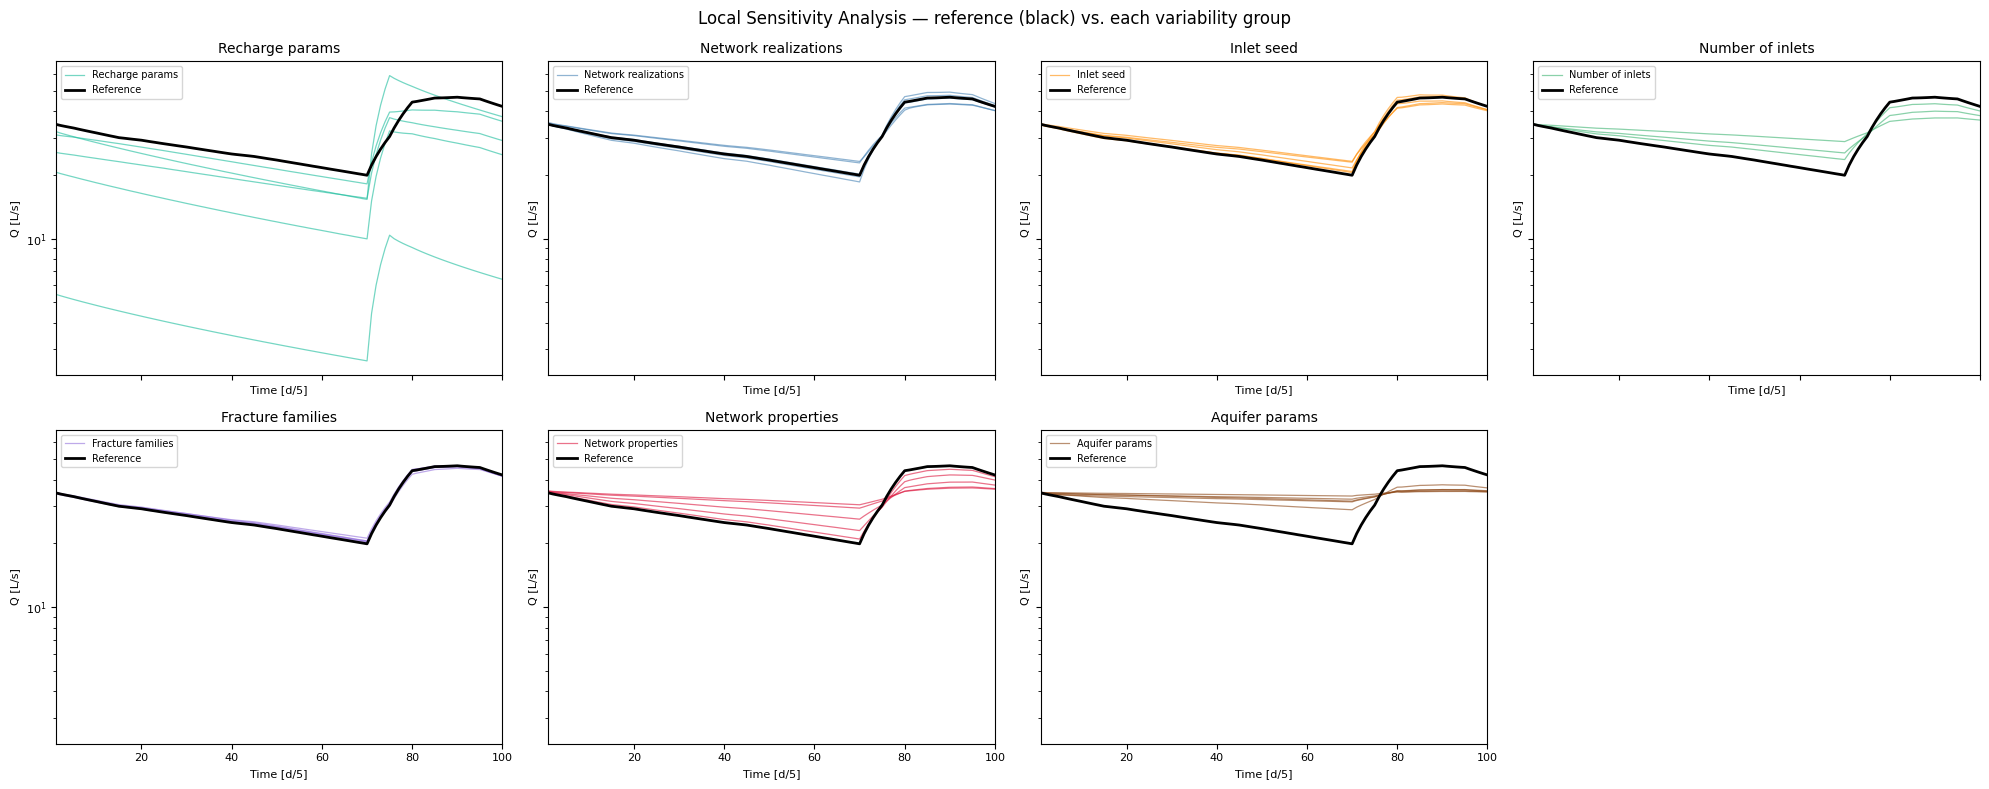

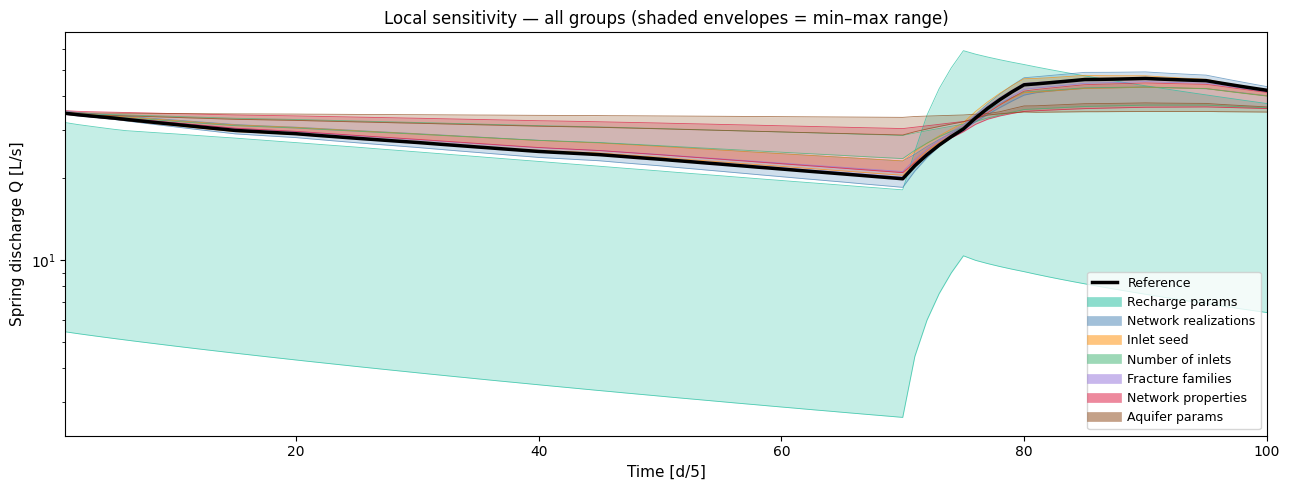

In [7]:
group_keys = ["G1", "G2", "G3", "G4", "G5", "G6", "G7"]


# ── Figure 1: individual group panels ────────────────────────────────────────
fig1, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()
axes_flat[-1].set_visible(False)  # hide unused 8th slot

for idx, gk in enumerate(group_keys):
    ax = axes_flat[idx]
    color = COLORS[gk]

    # Group simulations — thin, semi-transparent
    for i, q_arr in enumerate(results[gk]):
        q_ls = q_arr[1:] * 1000  # skip SS period, m³/s → L/s
        ax.plot(
            t, q_ls,
            color=color, lw=0.9, alpha=0.6,
            label=GROUP_LABELS[gk] if i == 0 else None,
        )

    # Reference — thick black
    ax.plot(t, Q_ref_plot, color=COLORS["ref"], lw=2.0, label="Reference")

    ax.set_yscale("log")
    ax.set_xlim(1, N_SP * NSTP)
    ax.set_title(GROUP_LABELS[gk], fontsize=10)
    ax.set_xlabel(f"Time [d/{NSTP}]", fontsize=8)
    ax.set_ylabel("Q [L/s]", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7)

plt.suptitle(
    "Local Sensitivity Analysis — reference (black) vs. each variability group",
    fontsize=12,
)
plt.tight_layout()
plt.show()


# ── Figure 2: combined envelope ───────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 5))

legend_handles = []

for gk in group_keys:
    if not results[gk]:
        continue
    color = COLORS[gk]

    # Stack into array: shape (n_runs, n_steps)
    qs = np.array([q[1:] * 1000 for q in results[gk]])
    q_min = qs.min(axis=0)
    q_max = qs.max(axis=0)

    ax2.fill_between(t, q_min, q_max, color=color, alpha=0.25, linewidth=0)
    ax2.plot(t, q_min, color=color, lw=0.6, alpha=0.7)
    ax2.plot(t, q_max, color=color, lw=0.6, alpha=0.7)

    legend_handles.append(
        mlines.Line2D(
            [], [], color=color, linewidth=7, alpha=0.5,
            label=GROUP_LABELS[gk],
        )
    )

# Reference on top
ax2.plot(t, Q_ref_plot, color=COLORS["ref"], lw=2.5, zorder=10)
legend_handles.insert(
    0,
    mlines.Line2D([], [], color=COLORS["ref"], linewidth=2.5, label="Reference"),
)

ax2.set_yscale("log")
ax2.set_xlim(1, N_SP * NSTP)
ax2.set_xlabel(f"Time [d/{NSTP}]", fontsize=11)
ax2.set_ylabel("Spring discharge Q [L/s]", fontsize=11)
ax2.set_title(
    "Local sensitivity — all groups (shaded envelopes = min–max range)",
    fontsize=12,
)
ax2.legend(handles=legend_handles, fontsize=9, loc="lower right", framealpha=0.8)
plt.tight_layout()
plt.show()